# CNN with Time Series Image Encoding (GAF + MTF)

**Docker image**: `ml4t-gpu`

This notebook converts time series windows into 2D images using **Gramian Angular
Fields** (GAF) and **Markov Transition Fields** (MTF), then trains a standard CNN
to regress on forward returns. The approach reformulates forecasting as image
regression, allowing convolutional networks to detect visual patterns in the
encoded representations.

**Learning Objectives**:
- Implement Gramian Angular Summation Fields (GASF) that encode pairwise
  angular sums
- Implement Markov Transition Fields (MTF) that encode transition probabilities
  between discretized states
- Stack GAF + MTF as multi-channel images and train a CNN regressor on
  forward returns
- Compare CNN-on-images against a Ridge+PCA baseline on the same flattened
  image pixels, evaluated by MSE and Spearman IC

**Book Reference**: Chapter 13, Section 13.6 (The Full Practitioner Toolkit)

**Prerequisites**: ETF features (`case_studies/etfs/`)

In [1]:
"""CNN with Time Series Image Encoding - convert time series to GAF/MTF images for forward-return regression."""

import os
import warnings

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

from dl_sequences import create_sequences_multi_asset, load_dl_dataset, train_model

In [2]:
SEED = 42
LOOKBACK = 20
IMAGE_SIZE = 32
EPOCHS = 10
BATCH_SIZE = 64
LR = 1e-4
DROPOUT = 0.5
MAX_TRAIN_SAMPLES = 40_000
MAX_VAL_SAMPLES = 10_000
MAX_TEST_SAMPLES = 10_000
INFER_BATCH_SIZE = 1_024
LABEL_HORIZON = 21

In [3]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

Device: cuda


## Data Loading

We use the five-day ETF return from the case-study pipeline. Both models see
exactly the same one-feature windows.

In [4]:
mds = load_dl_dataset("etfs")

FEATURE_COLS = ["ret_5d"]
TARGET_COL = mds.label_col

missing_features = sorted(set(FEATURE_COLS) - set(mds.feature_names))
if missing_features:
    raise ValueError(f"Missing required ETF return features: {missing_features}")

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")

Loaded etfs: 394,233 rows, 71 features, 99 entities, label=fwd_ret_21d
Features (1): ['ret_5d']
Target: fwd_ret_21d


## Sequence Creation and Temporal Split

In [5]:
df = mds.dataset.drop_nulls(subset=FEATURE_COLS + [TARGET_COL])
print(f"Rows after dropping nulls: {len(df):,}")

X, y, timestamps, symbols = create_sequences_multi_asset(
    df,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
    timestamp_col=mds.date_col,
    symbol_col=mds.entity_cols[0],
)
print(f"Sequences: {X.shape[0]:,}, shape: {X.shape}")

sequence_order = np.lexsort((symbols.astype(str), timestamps))
X = np.nan_to_num(X[sequence_order], nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
y = np.nan_to_num(y[sequence_order], nan=0.0).astype(np.float32)
timestamps = timestamps[sequence_order]
symbols = symbols[sequence_order]

Rows after dropping nulls: 394,233


Sequences: 392,253, shape: (392253, 20, 1)


In [6]:
# Date-based 60/20/20 temporal split. The target is a 21-day forward return,
# so labels whose outcome windows cross the next boundary are purged.
unique_dates = np.sort(np.unique(timestamps))
train_boundary_idx = int(len(unique_dates) * 0.6)
val_boundary_idx = int(len(unique_dates) * 0.8)
train_end_date = unique_dates[train_boundary_idx]
val_end_date = unique_dates[val_boundary_idx]
train_label_cutoff = unique_dates[train_boundary_idx - LABEL_HORIZON]
val_label_cutoff = unique_dates[val_boundary_idx - LABEL_HORIZON]

train_mask = timestamps < train_label_cutoff
val_mask = (timestamps >= train_end_date) & (timestamps < val_label_cutoff)
test_mask = timestamps >= val_end_date

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
test_dates, test_symbols = timestamps[test_mask], symbols[test_mask]

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")
print(
    f"Purged {LABEL_HORIZON} target dates before each boundary before complete-date subsampling: "
    f"validation starts {train_end_date}, test starts {val_end_date}"
)

Train: 210,440, Val: 88,454, Test: 89,348
Purged 21 target dates before each boundary before complete-date subsampling: validation starts 2018-05-17, test starts 2022-02-22


### Pedagogical subsampling

The GAF/MTF encoding loop produces one (image_size x image_size x 2) tensor
per sample, so the full ETF panel takes considerable wall-clock to encode.
We cap each split at a few tens of thousands of sequences for tractable
runtime. Critically we subsample by **complete dates**, not row count: the
sequence array can begin or end partway through a date, so a raw row slice
would leave a partial cross-section. Keeping the most recent complete dates
instead gives a stable, full cross-section that reproduces across runs.

In [7]:
def _trim_by_complete_dates(X_arr, y_arr, ts_arr, sym_arr, max_samples):
    """Keep the most recent whole dates whose total rows fit under `max_samples`."""
    if len(X_arr) <= max_samples:
        return X_arr, y_arr, ts_arr, sym_arr
    unique_ts = np.sort(np.unique(ts_arr))[::-1]
    cumulative = 0
    keep_dates: list = []
    for ts in unique_ts:
        n = int((ts_arr == ts).sum())
        if cumulative + n > max_samples and keep_dates:
            break
        cumulative += n
        keep_dates.append(ts)
    keep_mask = np.isin(ts_arr, np.array(keep_dates))
    return X_arr[keep_mask], y_arr[keep_mask], ts_arr[keep_mask], sym_arr[keep_mask]


X_train, y_train, _train_ts, _train_sym = _trim_by_complete_dates(
    X_train, y_train, timestamps[train_mask], symbols[train_mask], MAX_TRAIN_SAMPLES
)
X_val, y_val, _val_ts, _val_sym = _trim_by_complete_dates(
    X_val, y_val, timestamps[val_mask], symbols[val_mask], MAX_VAL_SAMPLES
)
X_test, y_test, test_dates, test_symbols = _trim_by_complete_dates(
    X_test, y_test, test_dates, test_symbols, MAX_TEST_SAMPLES
)

print(f"Capped split: Train={len(X_train):,}, Val={len(X_val):,}, Test={len(X_test):,}")

Capped split: Train=39,986, Val=9,975, Test=9,951


### Cross-sectional IC helper

Mean cross-sectional Spearman IC by date - same metric used in the rest of
Chapter 13 so the Image-CNN result is comparable with the other
architectures.

In [8]:
def cross_sectional_ic_mean(y_true, y_pred, dates, syms):
    """Mean cross-sectional Spearman IC across dates."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")

## Gramian Angular Summation Field (GASF)

The GASF encodes a time series as a matrix of trigonometric sums. Given a
normalized series $\tilde{x}_i \in [-1, 1]$, we compute angles
$\phi_i = \arccos(\tilde{x}_i)$ and form:

$$\text{GASF}_{i,j} = \cos(\phi_i + \phi_j)$$

This preserves temporal ordering. The diagonal evaluates to
$\cos(2\phi_i) = 2\tilde{x}_i^2 - 1$ - a deterministic function of the
normalized value, not the value itself - while off-diagonal entries capture
pairwise angular relationships between time steps $i$ and $j$.

In [9]:
def gramian_angular_field(series: np.ndarray, image_size: int) -> np.ndarray:
    """Compute the Gramian Angular Summation Field (GASF).

    Args:
        series: 1D array of shape (T,) -- raw feature values for one window
        image_size: Output image dimension (image_size x image_size)

    Returns:
        GASF matrix of shape (image_size, image_size) with values in [-1, 1]
    """
    # Resample to image_size via linear interpolation
    target_positions = np.linspace(0, len(series) - 1, image_size)
    source_positions = np.arange(len(series))
    resampled = np.interp(target_positions, source_positions, series)

    # Min-max scale to [-1, 1]
    s_min, s_max = resampled.min(), resampled.max()
    if s_max - s_min < 1e-8:
        return np.zeros((image_size, image_size), dtype=np.float32)
    scaled = 2.0 * (resampled - s_min) / (s_max - s_min) - 1.0
    scaled = np.clip(scaled, -1.0, 1.0)

    # Compute angular representation
    phi = np.arccos(scaled)

    # GASF: cos(phi_i + phi_j)
    gasf = np.cos(phi[:, None] + phi[None, :])
    return gasf.astype(np.float32)

## Markov Transition Field (MTF)

The MTF discretizes a time series into $Q$ quantile bins and builds a
transition matrix $W$ where $W_{q_i, q_j}$ is the probability of
transitioning from bin $q_i$ to bin $q_j$. The full MTF matrix is:

$$\text{MTF}_{i,j} = W_{q_i, q_j}$$

where $q_i$ is the quantile bin of the $i$-th timestep. This captures the
dynamic transition structure of the series.

In [10]:
def markov_transition_field(series: np.ndarray, image_size: int, n_bins: int = 8) -> np.ndarray:
    """Compute the Markov Transition Field (MTF).

    Args:
        series: 1D array of shape (T,) -- raw feature values for one window
        image_size: Output image dimension (image_size x image_size)
        n_bins: Number of quantile bins for discretization

    Returns:
        MTF matrix of shape (image_size, image_size) with values in [0, 1]
    """
    # Resample to image_size via linear interpolation
    target_positions = np.linspace(0, len(series) - 1, image_size)
    source_positions = np.arange(len(series))
    resampled = np.interp(target_positions, source_positions, series)

    # Discretize into quantile bins
    bin_edges = np.percentile(resampled, np.linspace(0, 100, n_bins + 1))
    bin_edges[-1] += 1e-8  # ensure max value is included
    bin_ids = np.digitize(resampled, bin_edges[1:-1])

    # Build transition matrix (n_bins x n_bins)
    transition = np.zeros((n_bins, n_bins), dtype=np.float32)
    for t in range(len(bin_ids) - 1):
        transition[bin_ids[t], bin_ids[t + 1]] += 1

    # Normalize rows to get probabilities
    row_sums = transition.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    transition /= row_sums

    # Build MTF: entry (i, j) = transition probability from bin at time i to bin at time j
    # Vectorized via advanced indexing (equivalent to the nested loop but ~100x faster)
    mtf = transition[np.ix_(bin_ids, bin_ids)]

    return mtf.astype(np.float32)

## Create Multi-Channel Image Dataset

For each one-feature sequence, we encode the return history as a GASF and an MTF,
then stack them as a 2-channel image. This gives the CNN both angular
structure (GASF) and transition dynamics (MTF) as complementary views.

> **Simplification**: This demo encodes only the five-day return history. A production
> system would encode all features, stacking GASF+MTF per feature to produce a
> $(2 \times F)$-channel image. We use one
> feature here to keep encoding time manageable and focus on the method itself.

In [11]:
def create_image_dataset(X_sequences: np.ndarray, image_size: int) -> np.ndarray:
    """Convert feature sequences into stacked GAF + MTF image tensors.

    For each sample, takes the return feature and computes both GASF
    and MTF encodings, returning a (N, 2, H, W) tensor.

    Args:
        X_sequences: Array of shape (N, lookback, n_features)
        image_size: Target image dimension (H = W = image_size)

    Returns:
        Image tensor of shape (N, 2, image_size, image_size)
    """
    n_samples = X_sequences.shape[0]
    images = np.zeros((n_samples, 2, image_size, image_size), dtype=np.float32)

    for i in range(n_samples):
        series = X_sequences[i, :, 0]
        images[i, 0] = gramian_angular_field(series, image_size)
        images[i, 1] = markov_transition_field(series, image_size)

        if (i + 1) % 10000 == 0 or i == n_samples - 1:
            print(f"  Encoded {i + 1:,}/{n_samples:,} samples")

    return images

## Encode Training, Validation, and Test Sets

In [12]:
print("Encoding training images...")
X_train_img = create_image_dataset(X_train, IMAGE_SIZE)
print(f"Train images: {X_train_img.shape}")

print("Encoding validation images...")
X_val_img = create_image_dataset(X_val, IMAGE_SIZE)
print(f"Val images: {X_val_img.shape}")

print("Encoding test images...")
X_test_img = create_image_dataset(X_test, IMAGE_SIZE)
print(f"Test images: {X_test_img.shape}")

Encoding training images...


  Encoded 10,000/39,986 samples


  Encoded 20,000/39,986 samples


  Encoded 30,000/39,986 samples


  Encoded 39,986/39,986 samples
Train images: (39986, 2, 32, 32)
Encoding validation images...


  Encoded 9,975/9,975 samples
Val images: (9975, 2, 32, 32)
Encoding test images...


  Encoded 9,951/9,951 samples
Test images: (9951, 2, 32, 32)


## Visualize Sample Encodings

Inspecting the GASF and MTF channels for a few training samples to verify
the encoding produces visually distinct patterns.

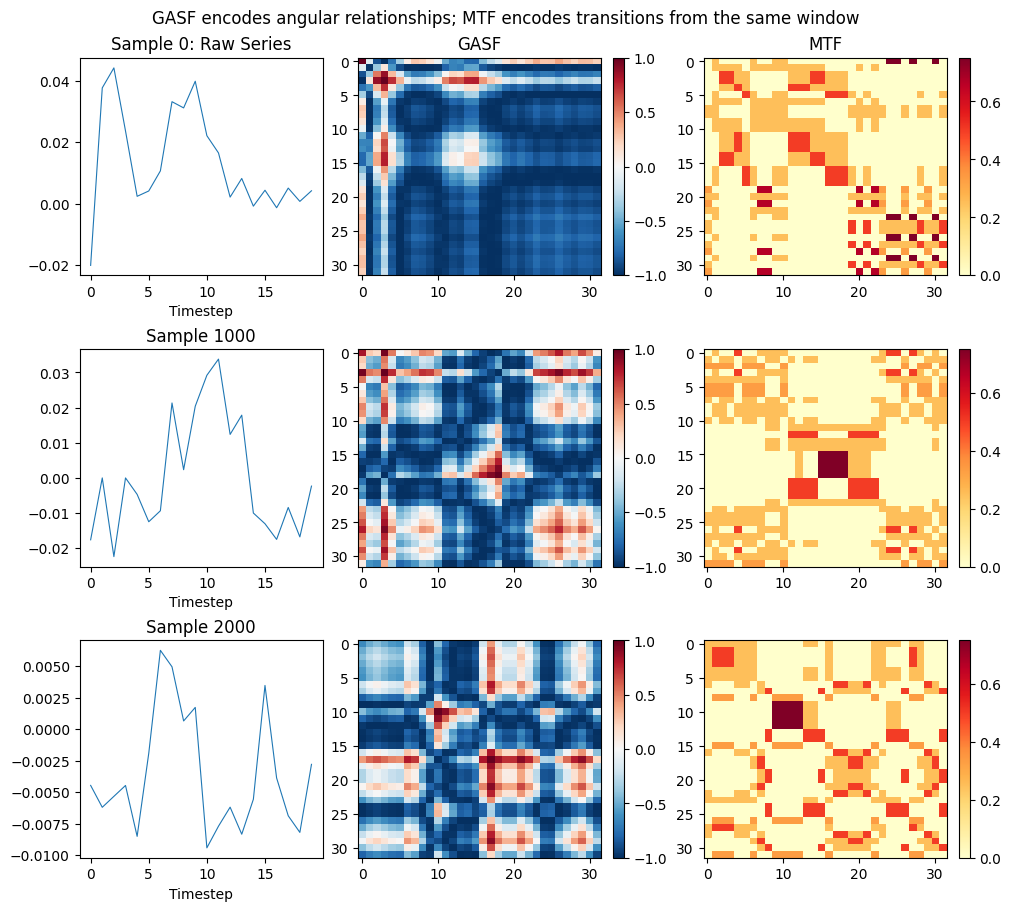

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(10, 9), constrained_layout=True)

for row in range(3):
    idx = row * 1000  # spread samples across the dataset
    if idx >= len(X_train_img):
        idx = row

    # Raw feature series
    axes[row, 0].plot(X_train[idx, :, 0], linewidth=0.8)
    axes[row, 0].set_title(f"Sample {idx}: Raw Series" if row == 0 else f"Sample {idx}")
    axes[row, 0].set_xlabel("Timestep")

    # GASF channel
    im1 = axes[row, 1].imshow(X_train_img[idx, 0], cmap="RdBu_r", aspect="auto")
    axes[row, 1].set_title("GASF" if row == 0 else "")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    # MTF channel
    im2 = axes[row, 2].imshow(X_train_img[idx, 1], cmap="YlOrRd", aspect="auto")
    axes[row, 2].set_title("MTF" if row == 0 else "")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

fig.suptitle("GASF encodes angular relationships; MTF encodes transitions from the same window")
fig.show()

## CNN Architecture

Three convolutional blocks (Conv2d $\to$ BatchNorm $\to$ ReLU $\to$ MaxPool)
followed by adaptive average pooling and a linear regression head.
The architecture is intentionally simple to isolate the contribution of
the image encoding from the model complexity.

In [14]:
class CNNBlock(nn.Module):
    """Single CNN building block: Conv2d -> BatchNorm -> ReLU -> MaxPool."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

### Full Image CNN

Three CNN blocks downsample the spatial dimensions by $2\times$ each,
followed by adaptive average pooling to a fixed-size vector regardless
of the input image size. Dropout before the final linear layer provides
regularization.

In [15]:
class ImageCNN(nn.Module):
    """CNN for regression on GAF+MTF encoded time series images.

    Architecture:
        Input (N, 2, H, W)
        -> CNNBlock(2, 32)   -> (N, 32, H/2, W/2)
        -> CNNBlock(32, 64)  -> (N, 64, H/4, W/4)
        -> CNNBlock(64, 128) -> (N, 128, H/8, W/8)
        -> AdaptiveAvgPool2d(1, 1) -> (N, 128)
        -> Dropout -> Linear -> (N, 1)
    """

    def __init__(self, n_channels: int = 2, dropout: float = 0.5):
        super().__init__()
        self.block1 = CNNBlock(n_channels, 32)
        self.block2 = CNNBlock(32, 64)
        self.block3 = CNNBlock(64, 128)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # flatten to (N, 128)
        x = self.dropout(x)
        return self.fc(x).squeeze(-1)  # (N,)

## Train the Image CNN

In [16]:
set_global_seeds(SEED)
model = ImageCNN(n_channels=2, dropout=DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"ImageCNN parameters: {n_params:,}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}, channels: 2 (GASF + MTF)")

history = train_model(model, X_train_img, y_train, X_val_img, y_val, EPOCHS, LR, BATCH_SIZE, DEVICE)

ImageCNN parameters: 93,537
Image size: 32x32, channels: 2 (GASF + MTF)


  Epoch 1/10: val_loss=0.003436


  Epoch 5/10: val_loss=0.003245


  Epoch 10/10: val_loss=0.002981


### Training convergence

The loss curves show whether the CNN is learning from the encoded images over
the configured training budget. A validation curve that stays flat while the
training curve falls signals the model is fitting noise the images do not
generalize.

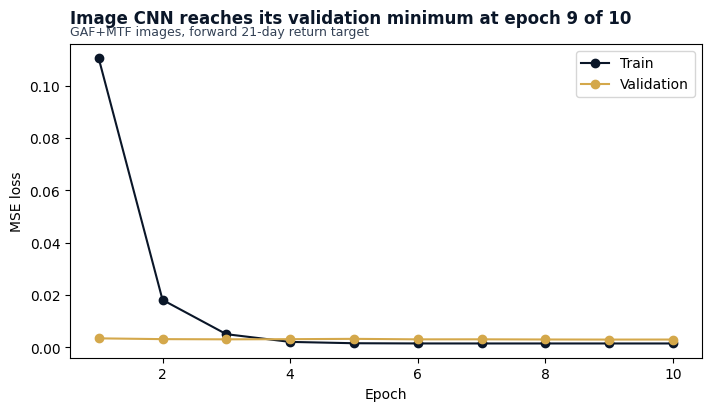

In [17]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
epochs_axis = range(1, len(history["train_loss"]) + 1)
ax.plot(epochs_axis, history["train_loss"], marker="o", color=COLORS["blue"], label="Train")
ax.plot(epochs_axis, history["val_loss"], marker="o", color=COLORS["amber"], label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
add_message_title(
    ax,
    f"Image CNN reaches its validation minimum at epoch {np.argmin(history['val_loss']) + 1} "
    f"of {len(history['val_loss'])}",
    subtitle="GAF+MTF images, forward 21-day return target",
)
fig.show()

## Evaluate on Test Set

In [18]:
model.eval()
with torch.no_grad():
    preds = []
    for i in range(0, len(X_test_img), INFER_BATCH_SIZE):
        X_test_t = torch.FloatTensor(X_test_img[i : i + INFER_BATCH_SIZE]).to(DEVICE)
        preds.append(model(X_test_t).cpu().numpy())
    y_pred = np.concatenate(preds, axis=0)

test_mse = np.mean((y_pred - y_test) ** 2)
test_ic = cross_sectional_ic_mean(y_test, y_pred, test_dates, test_symbols)

print("\nImage CNN Test Results:")
print(f"  MSE: {test_mse:.6f}")
print(f"  Spearman IC: {test_ic:.4f}")


Image CNN Test Results:
  MSE: 0.002006
  Spearman IC: -0.0133


## Ridge + PCA Baseline

Flatten the 2-channel images into vectors, reduce dimensionality with PCA
(100 components), then fit a Ridge regression. This tests whether the CNN
learns spatial structure beyond what a linear model can extract from the
same pixel representation.

In [19]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_test_flat = X_test_img.reshape(len(X_test_img), -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

n_components = min(100, X_train_scaled.shape[1], X_train_scaled.shape[0])
pca = PCA(n_components=n_components, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_pca, y_train)
y_ridge_pred = ridge.predict(X_test_pca)

ridge_mse = np.mean((y_ridge_pred - y_test) ** 2)
ridge_ic = cross_sectional_ic_mean(y_test, y_ridge_pred, test_dates, test_symbols)
zero_mse = float(np.mean(y_test**2))

print(f"\nRidge + PCA ({n_components} components) Baseline:")
print(f"  MSE: {ridge_mse:.6f}")
print(f"  Spearman IC: {ridge_ic:.4f}")


Ridge + PCA (100 components) Baseline:
  MSE: 0.001912
  Spearman IC: -0.0065


## Summary

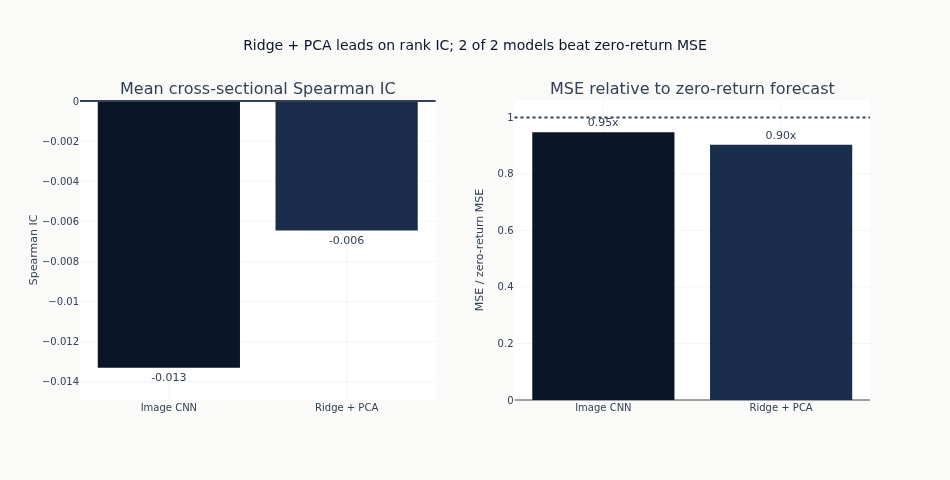

In [20]:
model_names = ["Image CNN", "Ridge + PCA"]
ic_values = [test_ic, ridge_ic]
mse_ratios = [test_mse / zero_mse, ridge_mse / zero_mse]
bar_palette = {"Image CNN": COLORS["blue"], "Ridge + PCA": COLORS["slate"]}

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Mean cross-sectional Spearman IC", "MSE relative to zero-return forecast"),
)
for model_name, ic_value, mse_ratio in zip(model_names, ic_values, mse_ratios, strict=True):
    fig.add_trace(
        go.Bar(
            x=[model_name],
            y=[ic_value],
            name=model_name,
            marker_color=bar_palette[model_name],
            text=[f"{ic_value:.3f}"],
            textposition="outside",
            showlegend=False,
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Bar(
            x=[model_name],
            y=[mse_ratio],
            name=model_name,
            marker_color=bar_palette[model_name],
            text=[f"{mse_ratio:.2f}x"],
            textposition="outside",
            showlegend=False,
        ),
        row=1,
        col=2,
    )

ic_leader = model_names[int(np.argmax(ic_values))]
mse_winners = sum(ratio < 1 for ratio in mse_ratios)
fig.add_hline(y=0, line_color=COLORS["neutral"], row=1, col=1)
fig.add_hline(y=1, line_dash="dot", line_color=COLORS["neutral"], row=1, col=2)
fig.update_layout(
    title=f"{ic_leader} leads on rank IC; {mse_winners} of 2 models beat zero-return MSE",
    width=950,
    height=480,
)
fig.update_yaxes(title_text="Spearman IC", row=1, col=1)
fig.update_yaxes(title_text="MSE / zero-return MSE", row=1, col=2)
fig.show()

## Interpretation

Treat this as a method illustration, not an architectural claim. On this
single-feature, single-split setup, the paired figure reports both
cross-sectional ranking and squared error relative to zero. Encoding a
single feature channel into a 2-channel GAF+MTF image does not by itself
establish a cross-sectional edge. The
representation is deliberately impoverished - one feature versus the
multi-feature sequence inputs the other architectures use - so the point here
is the encoding mechanics, visible in the GASF/MTF panels above, not a
performance verdict. Section 13.6 reviews published comparisons that encode
all features and benchmark against sequence-native models; those are the right
tests for the GAF/MTF representation as a class.

## Key Takeaways

1. **GAF encodes angular relationships**: The Gramian Angular Field maps
   pairwise temporal relationships into a symmetric matrix, preserving the
   original time ordering along the diagonal
2. **MTF captures transition dynamics**: The Markov Transition Field
   discretizes the series into quantile bins and encodes state-to-state
   transition probabilities, complementing the angular view
3. **Multi-channel images provide richer signal**: Stacking GASF and MTF
   as separate channels gives the CNN two complementary views of the same
   window, similar to RGB channels in natural images
4. **Encoding cost is non-trivial**: The per-sample image generation loop
   adds significant preprocessing overhead compared to feeding raw sequences
   directly to an LSTM or Transformer
5. **Representation differs from sequence-native models**: this notebook
   does not evaluate the CNN against LSTM/Transformer baselines or test
   ensembling - Section 13.6 reviews the published comparisons
6. **Single-feature encoding is a teaching simplification**: encoded
   representations come from one feature channel only, so single-split
   IC results are method illustrations rather than empirical claims
   about GAF/MTF + CNN versus Ridge as architectures in general

Deterministic PyTorch algorithms, a fixed cuBLAS workspace, and an explicit
PCA random state make repeated executions reproducible on the same software
and GPU stack; another environment may still produce small floating-point
differences.

**Next**: See `09_foundation_models` for pre-trained time series foundation
models that skip manual feature engineering entirely.
**Book**: Section 13.6 discusses image encoding alongside other alternative
representations in the full practitioner toolkit.